In [1]:
!python --version
import os
import warnings
print (os.environ['CONDA_DEFAULT_ENV'])

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.7.12
culRIBayes


In [2]:
import pandas as pd
import numpy as np
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd

import statsmodels.api as sm

import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px

from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path

from cmdstanpy import CmdStanModel
from culRIBayesian.stan_utils import get_posteriors, scaledRI_ensemble_from_temperature, scaledRI_ensemble_from_temp_gdgt23ratio
from culRIBayesian.stan_utils import temperature_ensemble_from_scaledRI, temperature_ensemble_from_scaledRI_gdgt23ratio

import bayspline as bsl
import bayspar as bsr

In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    lon1, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient



In [4]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten2002, schouten2003, kim2008, OBrien2017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten2002':(66.6667,-18.6667),
        'schouten2003':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien2017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_coretop_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_coretop_linear':(69.61698822,-16.73443208),
        'low23_coretop_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_coretop_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_coretop_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_coretop_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten2002, schouten2003, kim2008, OBrien2017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten2002':(0.015,0.280),
        'schouten2003':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien2017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_coretop_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_coretop_linear':(69.61698822,-16.73443208),
        'low23_coretop_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_coretop_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_coretop_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_coretop_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

In [5]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


In [6]:
# set the path to local folder other than github
login_name = os.getlogin()
### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('culRI-Bayesian')+len('culRI-Bayesian')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'


### stan_models path 
stan_models_path = local_github_path+'/stan_models/'

In [7]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_growthrate = culture_meso_df[culture_meso_df['experiment_setup'].isin(['Culture-growth-rate','Culture-oxygen'])].reset_index(drop=True)  
culture_meso_df = culture_meso_df[culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])].reset_index(drop=True)
culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
# culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Sinninghe Damste et al. (2002) Journal of Lipid Research'].reset_index(drop=True)
culture_meso_df['Strains_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['Strains'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]

culture_meso_df['GTDB_genus_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['GTDB_genus'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['GTDB_genus_edited'].iloc[i] = culture_meso_df['GTDB_genus'].iloc[i]

culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
culture_meso_df


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
126,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
127,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
128,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles


In [8]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds = xr.open_dataset(os.path.join(fpath, fname))
display(ocean_properties_ds)

fpath = f'{local_github_path}/nc_files/'
fname = 'ds04_gridded_coretop_tex_scaledRI.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

<xarray.Dataset>
Dimensions:                (lat: 720, lon: 1440)
Coordinates:
  * lat                    (lat) float32 -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                    (lon) float32 -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables: (12/14)
    region_ID              (lon, lat) float64 ...
    tex_count              (lon, lat) float64 ...
    tex_median             (lon, lat) float64 ...
    tex_mean               (lon, lat) float64 ...
    tex_std                (lon, lat) float64 ...
    scaledRI_count         (lon, lat) float64 ...
    ...                     ...
    scaledRI_std           (lon, lat) float64 ...
    gdgt23ratio_count      (lon, lat) float64 ...
    gdgt23ratio_median     (lon, lat) float64 ...
    gdgt23ratio_mean       (lon, lat) float64 ...
    gdgt23ratio_std        (lon, lat) float64 ...
    modernWaterDepth_mean  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [9]:
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])
coretop_da = coretop_ds_merged.to_dataframe().dropna(subset=['scaledRI_median','t_sf2tc_avg']).reset_index()
coretop_da

,lat,lon,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,scaledRI_mean,...,gdgt23ratio_count,gdgt23ratio_median,gdgt23ratio_mean,gdgt23ratio_std,modernWaterDepth_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc
0,-77.875,-40.375,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,0.509982,...,1.0,1.502839,1.502839,NaN,928.0,NaN,NaN,-1.636017,30.0,-1.75611
1,-77.375,-158.375,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,0.438075,...,1.0,2.833333,2.833333,NaN,1081.0,NaN,NaN,-1.586854,50.0,-1.66971
2,-77.125,-45.375,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,0.410931,...,1.0,1.824832,1.824832,NaN,332.0,NaN,NaN,-1.692642,30.0,-1.76631
3,-76.625,-35.375,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,0.433342,...,1.0,2.066396,2.066396,NaN,932.0,28.365620,28.426125,-1.498910,10.0,-1.56971
4,-76.375,-33.875,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,0.447518,...,1.0,2.040640,2.040640,NaN,839.0,29.118933,29.757280,-1.651191,40.0,-1.75551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1474,84.875,40.625,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,0.459150,...,1.0,4.516129,4.516129,NaN,4018.0,7.665815,9.033155,-1.373924,125.0,0.08159
1475,86.625,152.125,3.0,1.0,0.490000,0.490000,NaN,1.0,0.382600,0.382600,...,1.0,21.272727,21.272727,NaN,1467.0,7.059811,9.083502,-1.156047,175.0,0.24909
1476,86.875,-146.125,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,0.399850,...,1.0,9.555556,9.555556,NaN,3368.0,8.384475,9.424562,-1.477433,150.0,-0.88321
1477,87.125,104.625,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,0.433075,...,1.0,2.870370,2.870370,NaN,4443.0,6.828367,8.589128,-1.377392,150.0,-0.05211


In [10]:
def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

In [12]:

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

# ─── prepare sample points ────────────────────────────────────────────────────
xx = np.linspace(-4, 50, 200)

# ─── filter & group your data ──────────────────────────────────────────────────
plot_data = culture_meso_df[culture_meso_df['Temperature'] < 50]
min_count = 2
groups = [g for g, df in plot_data.groupby('Strains_edited') if len(df) >= min_count]

# ─── build the figure with one trace per strain per model ─────────────────────
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=coretop_da['t_sf2tc_avg'],
    y=coretop_da['scaledRI_median'],
    mode='markers',
    marker=dict(color='rgba(178,178,178,1.000)', size=5),
    name='Core-top data',
    showlegend=True   # you can allow toggling it via legend if you like
))
core_idx = 0  # index of this core-top trace

# ─── add global fits ────────────────────────────────────────────────
X_all = plot_data['Temperature'].values.reshape(-1,1)
y_all = plot_data['scaledRI'].values

# -- Linear fit --
ols_all = LinearRegression().fit(X_all, y_all)
y_lin_all = ols_all.predict(xx.reshape(-1,1))


# -- Logistic fixed upper --
p0f = [25, 0.1, 0.1]
bf = (0, [50,1,1])
popt_f_all, _ = curve_fit(logistic_fixed_upper, plot_data['Temperature'], plot_data['scaledRI'], p0=p0f, bounds=bf)
y_logif_all = logistic_fixed_upper(xx, *popt_f_all)
r2_logif_all = 1 - np.var(plot_data['scaledRI'] - logistic_fixed_upper(plot_data['Temperature'], *popt_f_all)) / np.var(plot_data['scaledRI'])

# -- Full logistic --
p0_all = [25,0.1,0.1,0.1]
bnd_all = (0, [50,1,1,1])
popt_all, _ = curve_fit(logistic, plot_data['Temperature'], plot_data['scaledRI'], p0=p0_all, bounds=bnd_all)
y_logi_all = logistic(xx, *popt_all)
r2_logi_all = 1 - np.var(plot_data['scaledRI'] - logistic(plot_data['Temperature'], *popt_all)) / np.var(plot_data['scaledRI'])

## add global fits to figure
for model, y, r2 in [
    ("Linear", y_lin_all, ols_all.score(X_all, y_all)),
    ("Logistic fixed", y_logif_all, r2_logif_all),
    ("Logistic", y_logi_all, r2_logi_all)
]:
    fig.add_trace(go.Scatter(
        x=xx, y=y,
        mode='lines',
        name=f"glob_cul_meso -- {model} (R²={r2:.2f})",
        visible=True
    ))

### add X_all and y_all with coretop data and fit the glob_cul_meso_coretop
X_all_full = np.concatenate((coretop_da['t_sf2tc_avg'].values.reshape(-1,1), plot_data['Temperature'].values.reshape(-1,1)))
y_all_full = np.concatenate((coretop_da['scaledRI_median'].values, plot_data['scaledRI'].values))

# -- Linear fit --
ols_all_full = LinearRegression().fit(X_all_full, y_all_full)
y_lin_all_full = ols_all_full.predict(xx.reshape(-1,1))
# -- Logistic fixed upper --
p0f_full = [25, 0.1, 0.1]
bf_full = (0, [50,1,1])
popt_f_all_full, _ = curve_fit(logistic_fixed_upper, np.squeeze(X_all_full), y_all_full, p0=p0f_full, bounds=bf_full)
y_logif_all_full = logistic_fixed_upper(xx, *popt_f_all_full)
r2_logif_all_full = 1 - np.var(y_all_full - logistic_fixed_upper(X_all_full, *popt_f_all_full)) / np.var(y_all_full)
# -- Full logistic --
p0_all_full = [25,0.1,0.1,0.1]
bnd_all_full = (0, [50,1,1,1])
popt_all_full, _ = curve_fit(logistic, np.squeeze(X_all_full), y_all_full, p0=p0_all_full, bounds=bnd_all_full)
y_logi_all_full = logistic(xx, *popt_all_full)
r2_logi_all_full = 1 - np.var(y_all_full - logistic(X_all_full, *popt_all_full)) / np.var(y_all_full)
## add global fits to figure
for model, y, r2 in [
    ("Linear", y_lin_all_full, ols_all_full.score(X_all_full, y_all_full)),
    ("Logistic fixed", y_logif_all_full, r2_logif_all_full),
    ("Logistic", y_logi_all_full, r2_logi_all_full)
]:
    fig.add_trace(go.Scatter(
        x=xx, y=y,
        mode='lines',
        name=f"glob_cul_meso_coretop -- {model} (R²={r2:.2f})",
        visible=True
    ))
    
# ─── add all your strain traces ───────────────────────────
for strain in groups:
    df = plot_data[plot_data['Strains_edited'] == strain]
    X = df['Temperature'].values.reshape(-1,1)
    y = df['scaledRI'].values
    
    # -- Linear fit --
    ols = LinearRegression().fit(X, y)
    y_lin = ols.predict(xx.reshape(-1,1))
    fig.add_trace(go.Scatter(
        x=xx, y=y_lin, 
        mode='lines',
        name=f"{strain} -- Linear (R²={ols.score(X,y):.2f})",
        visible=(strain == groups[0])  # only first strain visible initially
    ))
    
    # -- Logistic fixed upper --
    p0f = [25, 0.1, 0.1]
    bf = (0, [50,1,1])
    popt_f, _ = curve_fit(logistic_fixed_upper, df['Temperature'], df['scaledRI'], p0=p0f, bounds=bf)
    y_logf = logistic_fixed_upper(xx, *popt_f)
    r2_f = 1 - np.var(df['scaledRI'] - logistic_fixed_upper(df['Temperature'], *popt_f)) / np.var(df['scaledRI'])
    fig.add_trace(go.Scatter(
        x=xx, y=y_logf,
        mode='lines',
        name=f"{strain} -- Logistic fixed (R²={r2_f:.2f})",
        visible=False
    ))
    
    # -- Full logistic --
    p0 = [25,0.1,0.1,0.1]
    bnd = (0, [50,1,1,1])
    popt, _ = curve_fit(logistic, df['Temperature'], df['scaledRI'], p0=p0, bounds=bnd)
    y_log = logistic(xx, *popt)
    r2 = 1 - np.var(df['scaledRI'] - logistic(df['Temperature'], *popt)) / np.var(df['scaledRI'])
    fig.add_trace(go.Scatter(
        x=xx, y=y_log,
        mode='lines',
        name=f"{strain} -- Logistic (R²={r2:.2f})",
        visible=False
    ))
    
    # -- Always-on scatter of raw data --
    fig.add_trace(go.Scatter(
        x=df['Temperature'], y=df['scaledRI'],
        mode='markers',
        marker=dict(size=6, line=dict(width=1, color='black')),
        name=f"{strain} -- data",
        visible=True
    ))
# build a mapping strain → color
palette1 = px.colors.qualitative.Set1
palette2 = px.colors.qualitative.Set2

# make one long list
all_colors = palette1 + palette2

# then map strains in order
strain_colors = {
    strain: all_colors[i % len(all_colors)]
    for i, strain in enumerate(groups)
}

# now loop through all traces
for trace in fig.data:
    # The “cultures + mesocosm only” global fit
    if trace.name.startswith("glob_cul_meso --"):
        trace.update(line=dict(
            color="black",   # pick any CSS name or hex code
            dash="solid",        # “solid”, “dash”, “dot”, “dashdot”, etc
            width=4              # thicker line
        ))

    # The “cultures + mesocosm + coretop” global fit
    elif trace.name.startswith("glob_cul_meso_coretop --"):
        trace.update(line=dict(
            color="black",
            dash="dashdot",
            width=3
        ))
        
    # skip the core-top (and any other truly global or background traces)
    elif trace.name == "Core-top data":
        continue

    # split off the strain name (everything before the “ – ”)
    strain = trace.name.split(" -- ")[0]

    # pick a color: if it’s one of our strains, use its palette color;
    # otherwise (e.g. “Global”) fall back to black or whatever you like
    col = strain_colors.get(strain, "black")

    # apply to both marker & line
    trace.update(
        marker=dict(color=col),
        line=dict(color=col)
    )



# Hide all line traces (fits) by default, leave markers visible
for trace in fig.data:
    if "lines" in trace.mode:
        trace.visible = "legendonly"
    else:
        trace.visible = True

# # Make “raw data” the initial visibility state:
# for tr in fig.data:
#     if tr.name == "Core-top data" or tr.name.endswith("-- data"):
#         tr.visible = True
#     else:
#         tr.visible = False
        


# reposition the model‐dropdown as a vertical nav bar on the left
fig.update_layout(

    autosize=False,     # turn off responsive “fill the container”
    width=900,          # fixed pixel width
    height=500,         # fixed pixel height
    margin=dict(l=40, r=40, t=50, b=40),

    title="Scaled RI vs Temperature",
    xaxis_title="Temperature (°C)",
    yaxis_title="Scaled RI",
    
    yaxis=dict(
        range=[0.1, 1.1],
        autorange=False    # turn off auto‐scaling
    ),

    # put the legend also on the left, so users can click each strain on/off
    legend=dict(
        traceorder="normal",
        orientation="v",
        x=1.13,      # just inside the left margin
        y=0.5,
        xanchor="left",
        yanchor="middle",
        itemsizing="constant"
    ),
    template='seaborn',
    font=dict(
        family="TeX Gyre Heros",
        size=14,
        color="black"
    ),
    
)

# lock X/Y so the units match (remove if you don’t want a 1:1 scale)
fig.update_xaxes(constrain='domain')            # keep the X‐axis from expanding

# set a default
# fig.update_layout(template="plotly_white")

fig.show()

# in your Python script / notebook:
fig.write_html(
  os.path.join(local_github_path, 'html_figures', 'scaledRI_vs_Temperature.html'),
  include_plotlyjs="cdn",   # pull Plotly.js from the CDN
  full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
)


In [13]:
culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][
    culture_meso_df['datatype']=='culture'].dropna(subset=['Temperature','scaledRI']).reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][
    culture_meso_df['datatype']=='mesocosm'].dropna(subset=['Temperature','scaledRI']).reset_index(drop=True)
coretop_da = coretop_da.dropna(subset=['scaledRI_median','t_sf2tc_avg','gdgt23ratio_median']).reset_index(drop=True)
coretop_da = coretop_da[coretop_da['gdgt23ratio_median']<100].reset_index(drop=True)
coretop_da['gdgt23ratio_median'].max()

35.072441830778935

In [14]:
import culRIBayesian
print(culRIBayesian)
from culRIBayesian.stan_utils import get_posteriors, temperature_ensemble_from_scaledRI


<module 'culRIBayesian' from '/home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/__init__.py'>


In [15]:
# import cmdstanpy; cmdstanpy.install_cmdstan(overwrite=True)

In [16]:
x1 = culture_data_full['Temperature'].astype(float).tolist() 
y1 = culture_data_full['scaledRI'].astype(float).tolist() 

x2 = meso_data_full['Temperature'].astype(float).tolist()
y2 = meso_data_full['scaledRI'].astype(float).tolist()

x3 = coretop_da['t_sf2tc_avg'].astype(float).tolist()
y3 = coretop_da['scaledRI_median'].astype(float).tolist()
# Save data for Stan
data = {
    "N1": len(culture_data_full),
    "x1": x1,
    "y1": y1,
    "N2": len(meso_data_full),
    "x2": x2,
    "y2": y2,
}

stan_file_name = 'joint_culture_meso.stan'
joint_cul_meso_post_ds = get_posteriors(data, stan_file_name)
joint_cul_meso_post_ds


### cul + meso + coretop
data = {
    "N1": len(culture_data_full),
    "x1": x1,
    "y1": y1,
    "N2": len(meso_data_full),
    "x2": x2,
    "y2": y2,
    "N3": len(coretop_da),
    "x3": x3,
    "y3": y3,

}
stan_file_name = 'joint_culture_meso_coretop.stan'
joint_cul_meso_coretop_post_ds = get_posteriors(data, stan_file_name)
joint_cul_meso_coretop_post_ds




11:26:21 - cmdstanpy - INFO - Chain [1] start processing
11:26:21 - cmdstanpy - INFO - Chain [2] start processing
11:26:21 - cmdstanpy - INFO - Chain [3] start processing
11:26:21 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 500
Chain [1] save_warmup = 0 (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = 1 (Default)
Chain [1] gamma = 0.050000000000000003 (Default)
Chain [1] delta = 0.80000000000000004 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmpupq1bieu/3jngbl0x.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 42
Chain [1] output
Chain [1] file = /

11:26:22 - cmdstanpy - INFO - Chain [2] done processing
11:26:22 - cmdstanpy - INFO - Chain [4] done processing
11:26:22 - cmdstanpy - INFO - Chain [1] done processing
11:26:22 - cmdstanpy - INFO - Chain [3] done processing
11:26:22 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso.stan', line 44, column 2 to column 27)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso.stan', line 44, column 2 to column 27)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso.stan', line 44, column 2 to column 27)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie/Documents/GitHub

Chain [1] Iteration: 1200 / 1500 [ 80%]  (Sampling)
Chain [4] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [2] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 0.155 seconds (Warm-up)
Chain [2] 0.255 seconds (Sampling)
Chain [2] 0.41 seconds (Total)
Chain [2] 
Chain [2] 
Chain [3] Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain [4] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 0.163 seconds (Warm-up)
Chain [4] 0.236 seconds (Sampling)
Chain [4] 0.399 seconds (Total)
Chain [4] 
Chain [4] 
Chain [1] Iteration: 1300 / 1500 [ 86%]  (Sampling)
Chain [3] Iteration: 1200 / 1500 [ 80%]  (Sampling)
Chain [1] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [3] Iteration: 1300 / 1500 [ 86%]  (Sampling)
Chain [3] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [1] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 0.163 seconds (Warm-up)
Chain [1] 0.377 seconds (Sampling)
Chain [1] 0.54 seconds (Total)
Chain [1

11:26:22 - cmdstanpy - INFO - Chain [1] start processing
11:26:22 - cmdstanpy - INFO - Chain [2] start processing
11:26:22 - cmdstanpy - INFO - Chain [3] start processing
11:26:22 - cmdstanpy - INFO - Chain [4] start processing


...

11:26:28 - cmdstanpy - INFO - Chain [3] done processing


Chain [2] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [3] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 2.175 seconds (Warm-up)
Chain [3] 3.188 seconds (Sampling)
Chain [3] 5.363 seconds (Total)
Chain [3] 
Chain [3] 


11:26:28 - cmdstanpy - INFO - Chain [2] done processing
11:26:28 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop.stan', line 44, column 2 to column 27)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop.stan', line 44, column 2 to column 27)
	Exception: normal_lpdf: Location parameter[1] is nan, but must be finite! (in '/home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop.stan', line 44, column 2 to column 27)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop.stan', line 44, column 2 to column 27)
	Exception: normal_lpdf: Scale

Chain [2] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 2.349 seconds (Warm-up)
Chain [2] 3.196 seconds (Sampling)
Chain [2] 5.545 seconds (Total)
Chain [2] 
Chain [2] 


<xarray.Dataset>
Dimensions:        (draw: 4000)
Dimensions without coordinates: draw
Data variables:
    x0             (draw) float64 28.4 28.19 28.06 28.22 ... 28.25 27.98 28.1
    k              (draw) float64 0.1212 0.1235 0.1297 ... 0.1176 0.1283 0.1218
    b              (draw) float64 0.426 0.4308 0.4331 ... 0.422 0.429 0.4224
    sigma1         (draw) float64 0.09987 0.09885 0.08821 ... 0.1034 0.09133
    sigma2         (draw) float64 0.09511 0.08085 0.06629 ... 0.05234 0.08586
    sigma3         (draw) float64 0.05983 0.06072 0.05821 ... 0.05869 0.06005
    sigma2_sigma1  (draw) float64 0.9523 0.818 0.7515 ... 1.116 0.5064 0.9402
    sigma3_sigma1  (draw) float64 0.5991 0.6143 0.6599 ... 0.6807 0.5678 0.6576

In [18]:
### cul + meso + coretop with multivariate logistic
z3 = coretop_da['gdgt23ratio_median'].astype(float).tolist()
data = {
    "N1": len(culture_data_full),
    "x1": x1,
    "y1": y1,
    "N2": len(meso_data_full),
    "x2": x2,
    "y2": y2,
    "N3": len(coretop_da),
    "x3": x3,
    "y3": y3,
    "z3": z3
}


stan_file_name = 'joint_culture_meso_coretop_multivariate.stan'
joint_cul_meso_coretop_multivariate_post_ds = get_posteriors(data, stan_file_name)
joint_cul_meso_coretop_multivariate_post_ds

11:26:53 - cmdstanpy - INFO - compiling stan file /home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop_multivariate.stan to exe file /home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop_multivariate
11:27:38 - cmdstanpy - INFO - compiled model executable: /home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop_multivariate
11:27:38 - cmdstanpy - INFO - Chain [1] start processing
11:27:38 - cmdstanpy - INFO - Chain [2] start processing
11:27:38 - cmdstanpy - INFO - Chain [3] start processing
11:27:38 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 500
Chain [1] save_warmup = 0 (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = 1 (Default)
Chain [1] gamma = 0.050000000000000003 (Default)
Chain [1] delta = 0.80000000000000004 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmpupq1bieu/3j5rxxph.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 42
Chain [1] output
Chain [1] file = /

11:29:06 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 36.119 seconds (Warm-up)
Chain [1] 51.371 seconds (Sampling)
Chain [1] 87.49 seconds (Total)
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain 

11:29:11 - cmdstanpy - INFO - Chain [3] done processing


...

11:29:11 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 52.511 seconds (Warm-up)
Chain [2] 40.12 seconds (Sampling)
Chain [2] 92.631 seconds (Total)
Chain [2] 
Chain [2] 


11:29:12 - cmdstanpy - INFO - Chain [4] done processing
11:29:12 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop_multivariate.stan', line 57, column 2 to column 27)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop_multivariate.stan', line 57, column 2 to column 27)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop_multivariate.stan', line 57, column 2 to column 27)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop_multivariate.stan', line 57, column

Chain [4] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 49.171 seconds (Warm-up)
Chain [4] 44.513 seconds (Sampling)
Chain [4] 93.684 seconds (Total)
Chain [4] 
Chain [4] 


<xarray.Dataset>
Dimensions:        (draw: 4000)
Dimensions without coordinates: draw
Data variables:
    x0             (draw) float64 28.76 29.02 28.54 28.74 ... 28.42 28.43 28.38
    k              (draw) float64 0.1144 0.1124 0.1165 ... 0.1092 0.1089 0.108
    b              (draw) float64 0.3652 0.3525 0.3606 ... 0.3698 0.3722 0.3706
    beta1          (draw) float64 0.08881 0.08981 0.08403 ... 0.06863 0.07058
    beta0          (draw) float64 -0.006828 -0.00566 ... -0.006264 -0.006631
    sigma1         (draw) float64 0.0787 0.08875 0.07675 ... 0.07482 0.07775
    sigma2         (draw) float64 0.1106 0.1201 0.109 ... 0.08751 0.09606
    sigma3         (draw) float64 0.05627 0.05651 0.0566 ... 0.0558 0.05554
    sigma2_sigma1  (draw) float64 1.405 1.353 1.42 1.339 ... 1.097 1.17 1.236
    sigma3_sigma1  (draw) float64 0.715 0.6367 0.7375 ... 0.7229 0.7458 0.7143

In [19]:
# locate the stan_models folder next to the culRIBayesian package
pkg_dir  = Path(culRIBayesian.__file__).parent
stan_dir = pkg_dir / "stan_models"

# list all .stan files
stan_files = sorted(p.name for p in stan_dir.glob("*.stan"))
print(stan_files)


['bernoulli.stan', 'coretop_combined.stan', 'coretop_regression_kde_inside.stan', 'coretop_regression_post_stats.stan', 'joint_culture_meso.stan', 'joint_culture_meso_coretop.stan', 'joint_culture_meso_coretop_multivariate.stan', 'joint_culture_meso_coretop_multivariate_fixedbeta1.stan', 'logistic_fixed_asymptote.stan', 'logistic_fixed_asymptote_post-to-prior.stan', 'logistic_fixed_asymptote_seq.stan', 'test_model.stan']


In [21]:
### cul + meso + coretop with multivariate logistic
z3 = coretop_da['gdgt23ratio_median'].astype(float).tolist()
data = {
    "N1": len(culture_data_full),
    "x1": x1,
    "y1": y1,
    "N2": len(meso_data_full),
    "x2": x2,
    "y2": y2,
    "N3": len(coretop_da),
    "x3": x3,
    "y3": y3,
    "z3": z3
}


stan_file_name = 'joint_culture_meso_coretop_multivariate_fixedbeta1.stan'
joint_cul_meso_coretop_multivariate_fixedbeta1_post_ds = get_posteriors(data, stan_file_name)
joint_cul_meso_coretop_multivariate_fixedbeta1_post_ds

11:57:15 - cmdstanpy - INFO - compiling stan file /home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop_multivariate_fixedbeta1.stan to exe file /home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop_multivariate_fixedbeta1
11:57:59 - cmdstanpy - INFO - compiled model executable: /home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop_multivariate_fixedbeta1
11:57:59 - cmdstanpy - INFO - Chain [1] start processing
11:57:59 - cmdstanpy - INFO - Chain [2] start processing
11:57:59 - cmdstanpy - INFO - Chain [3] start processing
11:57:59 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 500
Chain [1] save_warmup = 0 (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = 1 (Default)
Chain [1] gamma = 0.050000000000000003 (Default)
Chain [1] delta = 0.80000000000000004 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmpupq1bieu/f5gh1j53.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 42
Chain [1] output
Chain [1] file = /

11:58:51 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 20.533 seconds (Warm-up)
Chain [1] 31.038 seconds (Sampling)
Chain [1] 51.571 seconds (Total)
Chain [1] 
Chain [1] 
Chain [1] 
Chain [2] Iteration: 1200 / 1500 [ 80%]  (Sampling)
Chain [3] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [4] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [2] Iteration: 1300 / 1500 [ 86%]  (Sampling)


11:58:55 - cmdstanpy - INFO - Chain [3] done processing


...

11:58:57 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 22.083 seconds (Warm-up)
Chain [4] 35.619 seconds (Sampling)
Chain [4] 57.702 seconds (Total)
Chain [4] 
Chain [4] 


11:58:59 - cmdstanpy - INFO - Chain [2] done processing
11:58:59 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Location parameter[1] is nan, but must be finite! (in '/home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop_multivariate_fixedbeta1.stan', line 54, column 2 to column 27)
	Exception: normal_lpdf: Location parameter[1] is nan, but must be finite! (in '/home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop_multivariate_fixedbeta1.stan', line 54, column 2 to column 27)
	Exception: normal_lpdf: Location parameter[1] is nan, but must be finite! (in '/home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop_multivariate_fixedbeta1.stan', line 54, column 2 to column 27)
	Exception: normal_lpdf: Location parameter[1] is nan, but must be finite! (in '/home/ronnie/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint

Chain [2] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 30.806 seconds (Warm-up)
Chain [2] 28.422 seconds (Sampling)
Chain [2] 59.228 seconds (Total)
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain

<xarray.Dataset>
Dimensions:        (draw: 4000)
Dimensions without coordinates: draw
Data variables:
    x0             (draw) float64 26.64 26.59 26.55 26.97 ... 26.74 26.78 26.71
    k              (draw) float64 0.1175 0.1209 0.1113 ... 0.1315 0.1237 0.1217
    b              (draw) float64 0.4501 0.4433 0.4405 ... 0.4556 0.4546 0.4502
    beta0          (draw) float64 -0.006368 -0.005606 ... -0.005941 -0.006042
    sigma1         (draw) float64 0.1075 0.1146 0.1254 ... 0.1262 0.1042 0.1076
    sigma2         (draw) float64 0.05487 0.0644 0.06616 ... 0.0675 0.06504
    sigma3         (draw) float64 0.05762 0.05517 0.05643 ... 0.05584 0.05522
    sigma2_sigma1  (draw) float64 0.5104 0.5617 0.5277 ... 0.6216 0.648 0.6047
    sigma3_sigma1  (draw) float64 0.536 0.4812 0.45 ... 0.429 0.5361 0.5134

(array([  12.,   75.,  266.,  803., 1135., 1018.,  496.,  155.,   36.,
           4.]),
 array([-0.00728384, -0.00696577, -0.00664769, -0.00632962, -0.00601155,
        -0.00569347, -0.0053754 , -0.00505733, -0.00473926, -0.00442118,
        -0.00410311]),
 [<matplotlib.patches.Polygon at 0x7f430aa16c90>])

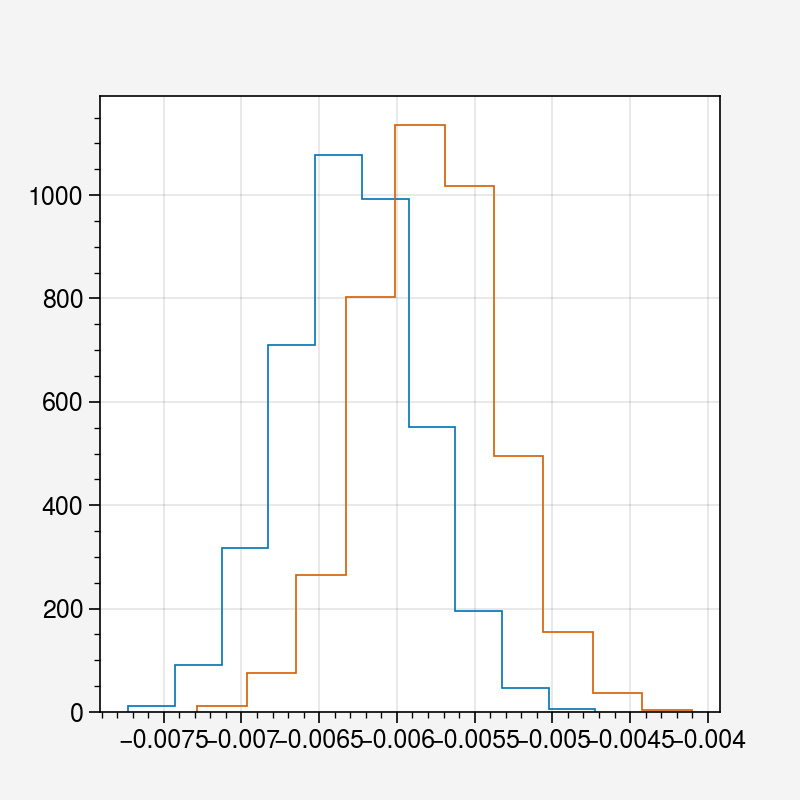

In [22]:
plt.hist(joint_cul_meso_coretop_multivariate_post_ds['beta0'],histtype='step')
plt.hist(joint_cul_meso_coretop_multivariate_fixedbeta1_post_ds['beta0'],histtype='step')

In [65]:
import numpy as np200
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display

### plot data
culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture'].reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm'].reset_index(drop=True)
coretop_da

# Set seed
np.random.seed(42)

fig = make_subplots(
    rows=5, cols=3,
    specs=[
        [{"rowspan": 3, "colspan": 3}, None,           None],  # row 1
        [None,                    None,             None],  # row 2 (big plot continues here)
        [None,                    None,             None],  # row 3 (big plot continues here)
        [{},                      {},             {}   ],   # row 4
        [{},                      {},             None ] # row 5
    ],
    # row_heights=[0.4, 0.3, 0.3],  # must have three entries now
    vertical_spacing=0.1,
    subplot_titles=(
        "T vs RI",           # this applies to the big plot

        "x0",                # row 2, col 3
        "k",                 # row 3, col 1
        "b",                 # row 3, col 2
        "beta0",
        "beta1",             # row 4, col 1
    )
)

### plot scatter plot in subplot 1

### plot core-top data in row 1, col 1
fig.add_trace(
    go.Scatter(
        x=coretop_da['t_sf2tc_avg'],
        y=coretop_da['scaledRI_median'],
        mode='markers',
        marker=dict(color='sandybrown', size=5, line=dict(width=0.5, color='black')),
        name='Core-top data',
        legendgroup='GDGT data',
        legendgrouptitle_text='GDGT data',
        showlegend=True
    ),
    row=1, col=1
)


### plot culture data
fig.add_trace(
    go.Scatter(
        x=culture_data_full['Temperature'],
        y=culture_data_full['scaledRI'],
        mode='markers',
        marker=dict(color='darkcyan', size=6, line=dict(width=1, color='black')),
        name='Culture data',
        legendgroup='GDGT data',
        legendgrouptitle_text='GDGT data',
        showlegend=True
    ),
    row=1, col=1
)

### plot mesocosm data
fig.add_trace(
    go.Scatter(
        x=meso_data_full['Temperature'],
        y=meso_data_full['scaledRI'],
        mode='markers',
        marker=dict(color='lightblue', size=6, line=dict(width=1, color='black')),
        name='Mesocosm data',
        legendgroup='GDGT data',
        legendgrouptitle_text='GDGT data',
        showlegend=True
    ),
    row=1, col=1
)

### plot calibration curves with confidence intervals | joint_cul_meso
xx = np.linspace(-4, 50, 200)
yy = scaledRI_ensemble_from_temperature(xx, joint_cul_meso_post_ds, model_name='logistic_fixed_upper')
yy_P50 = np.percentile(yy, 50, axis=1)
yy_P5 = np.percentile(yy, 5, axis=1)
yy_P95 = np.percentile(yy, 95, axis=1)
### plot P50 as a line
fig.add_trace(
    go.Scatter(
        x=xx,
        y=yy_P50,
        mode='lines',
        line=dict(color='darkcyan', width=2),
        name='P50 (joint-cul-meso)',
        legendgroup='joint-cul-meso',
        legendgrouptitle_text='joint-cul-meso',
        showlegend=True
    ),
    row=1, col=1
)

### plot P5 and P95 as a shaded area
fig.add_trace(
    go.Scatter(
        x=np.concatenate([xx, xx[::-1]]),  # x values for the area
        y=np.concatenate([yy_P5, yy_P95[::-1]]),  # y values for the area
        fill='toself',
        fillcolor='rgba(0,139,139, 0.2)',  # semi-transparent fill
        line=dict(color='rgba(0, 0, 0, 0)'),  # no line
        name='P5-P95 (joint-cul-meso)',
        legendgroup='joint-cul-meso',
        showlegend=True
    ),
    row=1, col=1
)

### plot calibration curves with confidence intervals | joint_cul_meso_coretop
xx = np.linspace(-4, 50, 200)
yy = scaledRI_ensemble_from_temperature(xx, joint_cul_meso_coretop_post_ds, model_name='logistic_fixed_upper')
yy_P50 = np.percentile(yy, 50, axis=1)
yy_P5 = np.percentile(yy, 5, axis=1)
yy_P95 = np.percentile(yy, 95, axis=1)

### plot P50 as a line
fig.add_trace(
    go.Scatter(
        x=xx,
        y=yy_P50,
        mode='lines',
        line=dict(color='black', width=2),
        name='P50 (joint-cul-meso-coretop)',
        legendgroup='joint-cul-meso-coretop',
        legendgrouptitle_text='joint-cul-meso-coretop',
        showlegend=True
    ),
    row=1, col=1
)

### plot P5 and P95 as a shaded area
fig.add_trace(
    go.Scatter(
        x=np.concatenate([xx, xx[::-1]]),  # x values for the area
        y=np.concatenate([yy_P5, yy_P95[::-1]]),  # y values for the area
        fill='toself',
        fillcolor='rgba(0, 0, 0, 0.5)',  # semi-transparent fill
        line=dict(color='rgba(0, 0, 0, 0)'),  # no line
        name='P5-P95 (joint-cul-meso-coretop)',
        legendgroup='joint-cul-meso-coretop',
        showlegend=True
    ),
    row=1, col=1
)

### plot calibration curves with confidence intervals | joint_cul_meso_coretop_multivariate
xx = np.linspace(-4, 50, 200)
yy = scaledRI_ensemble_from_temperature(xx, joint_cul_meso_coretop_multivariate_post_ds, model_name='logistic_fixed_upper')
yy_P50 = np.percentile(yy, 50, axis=1)
yy_P5 = np.percentile(yy, 5, axis=1)
yy_P95 = np.percentile(yy, 95, axis=1)
### plot P50 as a line
fig.add_trace(
    go.Scatter(
        x=xx,
        y=yy_P50,
        mode='lines',
        line=dict(color='darkorange', width=2),
        name='P50 (multivariate)',
        legendgroup='joint-cul-meso-coretop-multivariate',
        legendgrouptitle_text='joint-cul-meso-coretop-multivariate',
        showlegend=True
    ),
    row=1, col=1
)

### plot P5 and P95 as a shaded area
fig.add_trace(
    go.Scatter(
        x=np.concatenate([xx, xx[::-1]]),  # x values for the area
        y=np.concatenate([yy_P5, yy_P95[::-1]]),  # y values for the area
        fill='toself',
        fillcolor='rgba(255,140,0, 0.2)',  # semi-transparent fill
        line=dict(color='rgba(0, 0, 0, 0)'),  # no line
        name='P5-P95 (multivariate)',
        legendgroup='joint-cul-meso-coretop-multivariate',
        showlegend=True
    ),
    row=1, col=1
)

beta0_P50_freeBeta1 = np.percentile(
    joint_cul_meso_coretop_multivariate_post_ds['beta0'].values, 50, axis=0
)
beta1_P50_freeBeta1 = np.percentile(
    joint_cul_meso_coretop_multivariate_post_ds['beta1'].values, 50, axis=0
)

yy_P50_fixedbeta1_gdgt23_1 = yy_P50 + (
    beta0_P50_freeBeta1 * 1 + beta1_P50_freeBeta1
)
### plot P50 with gdgt23 ratio of 1
fig.add_trace(
    go.Scatter(
        x=xx,
        y=yy_P50_fixedbeta1_gdgt23_1,
        mode='lines',
        line=dict(color='darkorange', width=2, dash='solid'),
        name='P50 (multivariate, gdgt23=1)',
        legendgroup='joint-cul-meso-coretop-multivariate',
        showlegend=True
    ),
    row=1, col=1
)

yy_P50_freeBeta1_gdgt23_5 = yy_P50 + (
    beta0_P50_freeBeta1 * 5 + beta1_P50_freeBeta1
)
## plot P50 with gdgt23 ratio of 5
fig.add_trace(
    go.Scatter(
        x=xx,
        y=yy_P50_freeBeta1_gdgt23_5,
        mode='lines',
        line=dict(color='darkorange', width=2, dash='dash'),
        name='P50 (multivariate, gdgt23=5)',
        legendgroup='joint-cul-meso-coretop-multivariate',
        showlegend=True
    ),
    row=1, col=1
)

yy_P50_freeBeta1_gdgt23_15 = yy_P50 + (
    beta0_P50_freeBeta1 * 15 + beta1_P50_freeBeta1
)
### plot P50 with gdgt23 ratio of 15
fig.add_trace(
    go.Scatter(
        x=xx,
        y=yy_P50_freeBeta1_gdgt23_15,
        mode='lines',
        line=dict(color='darkorange', width=2, dash='dot'),
        name='P50 (multivariate, gdgt23=15)',
        legendgroup='joint-cul-meso-coretop-multivariate',
        showlegend=True
    ),
    row=1, col=1
)


### plot calibration curves with confidence intervals | joint_cul_meso_coretop_multivariate_fixedbeta1
xx = np.linspace(-4, 50, 200)
yy = scaledRI_ensemble_from_temperature(xx, joint_cul_meso_coretop_multivariate_fixedbeta1_post_ds, model_name='logistic_fixed_upper')
yy_P50 = np.percentile(yy, 50, axis=1)
yy_P5 = np.percentile(yy, 5, axis=1)
yy_P95 = np.percentile(yy, 95, axis=1)

### plot P50 as a line
fig.add_trace(
    go.Scatter(
        x=xx,
        y=yy_P50,
        mode='lines',
        line=dict(color='darkred', width=2),
        name='P50 (multivariate-fixedbeta1)',
        legendgroup='joint-cul-meso-coretop-multivariate-fixedbeta1',
        legendgrouptitle_text='joint-cul-meso-coretop-multivariate-fixedbeta1',
        showlegend=True
    ),
    row=1, col=1
)

### plot P5 and P95 as a shaded area
fig.add_trace(
    go.Scatter(
        x=np.concatenate([xx, xx[::-1]]),  # x values for the area
        y=np.concatenate([yy_P5, yy_P95[::-1]]),  # y values for the area
        fill='toself',
        fillcolor='rgba(255,0,0, 0.2)',  # semi-transparent fill
        line=dict(color='rgba(0, 0, 0, 0)'),  # no line
        name='P5-P95 (multivariate-fixedbeta1)',
        legendgroup='joint-cul-meso-coretop-multivariate-fixedbeta1',
        showlegend=True
    ),
    row=1, col=1
)

beta0_P50_fixedbeta1 = np.percentile(
    joint_cul_meso_coretop_multivariate_fixedbeta1_post_ds['beta0'].values, 50, axis=0
)

yy_P50_fixedbeta1_gdgt23_1 = yy_P50 + (
    beta0_P50_fixedbeta1 * 1
)
### plot P50 with gdgt23 ratio of 1
fig.add_trace(
    go.Scatter(
        x=xx,
        y=yy_P50_fixedbeta1_gdgt23_1,
        mode='lines',
        line=dict(color='darkred', width=2, dash='solid'),
        name='P50 (multivariate-fixedbeta1, gdgt23=1)',
        legendgroup='joint-cul-meso-coretop-multivariate-fixedbeta1',
        showlegend=True
    ),
    row=1, col=1
)

yy_P50_fixedbeta1_gdgt23_5 = yy_P50 + (
    beta0_P50_fixedbeta1 * 5
)

### plot P50 with gdgt23 ratio of 5
fig.add_trace(
    go.Scatter(
        x=xx,
        y=yy_P50_fixedbeta1_gdgt23_5,
        mode='lines',
        line=dict(color='darkred', width=2, dash='dash'),
        name='P50 (multivariate-fixedbeta1, gdgt23=5)',
        legendgroup='joint-cul-meso-coretop-multivariate-fixedbeta1',
        showlegend=True
    ),
    row=1, col=1
)

yy_P50_freeBeta1_gdgt23_15 = yy_P50 + (
    beta0_P50_fixedbeta1 * 15
)

### plot P50 with gdgt23 ratio of 15
fig.add_trace(
    go.Scatter(
        x=xx,
        y=yy_P50_freeBeta1_gdgt23_15,
        mode='lines',
        line=dict(color='darkred', width=2, dash='dot'),
        name='P50 (multivariate-fixedbeta1, gdgt23=15)',
        legendgroup='joint-cul-meso-coretop-multivariate-fixedbeta1',
        showlegend=True
    ),
    row=1, col=1
)
############################################################

# Add overlaid histograms
x0_prior0 = np.random.normal(20, 20, 1000)
x0_post_joint_cul_meso = joint_cul_meso_post_ds['x0'].values
x0_post_joint_cul_meso_coretop = joint_cul_meso_coretop_post_ds['x0'].values
plot_data_list = [
    (x0_prior0, 'x0 prior', 'gray', 'prior'),
    (x0_post_joint_cul_meso, 'x0 post (joint-cul-meso)', 'darkcyan', 'joint-cul-meso'),
    (x0_post_joint_cul_meso_coretop, 'x0 post (joint-cul-meso-coretop)', 'black', 'joint-cul-meso-coretop'),
    (joint_cul_meso_coretop_multivariate_post_ds['x0'].values, 
     'x0 post (multivariate)', 'darkorange', 'joint-cul-meso-coretop-multivariate'),
    (joint_cul_meso_coretop_multivariate_fixedbeta1_post_ds['x0'].values,
     'x0 post (multivariate-fixedbeta1)', 'darkred', 'joint-cul-meso-coretop-multivariate-fixedbeta1')
]
for data, label, color, lgg in plot_data_list:
    fig.add_trace(
        go.Histogram(
            x=data,
            name=label,
            histnorm='probability density',
            marker_color=color,
            opacity=0.5,
            xbins=dict(size=0.2),
            legendgroup=lgg,
            legendgrouptitle_text=lgg,
        ),
        row=4, col=1
    )


k_prior0 = np.random.normal(0, 0.25, 1000)
k_post_joint_cul_meso = joint_cul_meso_post_ds['k'].values
k_post_joint_cul_meso_coretop = joint_cul_meso_coretop_post_ds['k'].values
plot_data_list = [
    (k_prior0, 'k prior', 'gray', 'prior'),
    (k_post_joint_cul_meso, 'k post (joint-cul-meso)', 'darkcyan', 'joint-cul-meso'),
    (k_post_joint_cul_meso_coretop, 'k post (joint-cul-meso-coretop)', 'black', 'joint-cul-meso-coretop'),
    (joint_cul_meso_coretop_multivariate_post_ds['k'].values, 
     'k post (multivariate)', 
     'darkorange', 'joint-cul-meso-coretop-multivariate'),
    (joint_cul_meso_coretop_multivariate_fixedbeta1_post_ds['k'].values,
        'k post (multivariate-fixedbeta1)', 
        'darkred', 'joint-cul-meso-coretop-multivariate-fixedbeta1')
]
for data, label, color, lgg in plot_data_list:
    fig.add_trace(
        go.Histogram(
            x=data,
            name=label,
            histnorm='probability density',
            marker_color=color,
            opacity=0.5,
            xbins=dict(size=0.01),
            legendgroup=lgg,
            legendgrouptitle_text=lgg,
        ),
        row=4, col=2
    )

b_prior0 = np.random.beta(2,5,1000)
b_post_joint_cul_meso = joint_cul_meso_post_ds['b'].values
b_post_joint_cul_meso_coretop = joint_cul_meso_coretop_post_ds['b'].values

plot_data_list = [
    (b_prior0, 'b prior', 'gray', 'prior'),
    (b_post_joint_cul_meso, 'b post (joint-cul-meso)', 'darkcyan', 'joint-cul-meso'),
    (b_post_joint_cul_meso_coretop, 'b post (joint-cul-meso-coretop)', 'black', 'joint-cul-meso-coretop'),
    (joint_cul_meso_coretop_multivariate_post_ds['b'].values, 
     'b post (multivariate)', 
     'darkorange', 'joint-cul-meso-coretop-multivariate'),
    (joint_cul_meso_coretop_multivariate_fixedbeta1_post_ds['b'].values,
    'b post (multivariate-fixedbeta1)', 
    'darkred', 'joint-cul-meso-coretop-multivariate-fixedbeta1')
]

for data, label, color, lgg in plot_data_list:
    fig.add_trace(
        go.Histogram(
            x=data,
            name=label,
            histnorm='probability density',
            marker_color=color,
            opacity=0.5,
            xbins=dict(size=0.01),
            legendgroup=lgg,
            legendgrouptitle_text=lgg,
        ),
        row=4, col=3
    )

beta0_prior0 = np.random.normal(0, 0.01, 1000)
plot_data_list = [
    (beta0_prior0, 'beta0 prior', 'gray', 'prior'),
    (joint_cul_meso_coretop_multivariate_post_ds['beta0'].values, 
     'beta0 post (multivariate)', 
     'darkorange', 'joint-cul-meso-coretop-multivariate'),
    (joint_cul_meso_coretop_multivariate_fixedbeta1_post_ds['beta0'].values,
        'beta0 post (multivariate-fixedbeta1)', 
        'darkred', 'joint-cul-meso-coretop-multivariate-fixedbeta1')
]
for data, label, color, lgg in plot_data_list:
    fig.add_trace(
        go.Histogram(
            x=data,
            name=label,
            histnorm='probability density',
            marker_color=color,
            opacity=0.5,
            xbins=dict(size=0.0001),
            legendgroup=lgg,
            legendgrouptitle_text=lgg,
        ),
        row=5, col=1
    )

beta1_prior0 = np.random.normal(0, 0.1, 1000)
plot_data_list = [
    (beta1_prior0, 'beta1 prior', 'gray', 'prior'),
    (joint_cul_meso_coretop_multivariate_post_ds['beta1'].values, 
     'beta1 post (multivariate)', 
     'darkorange', 'joint-cul-meso-coretop-multivariate')]
for data, label, color, lgg in plot_data_list:
    fig.add_trace(
        go.Histogram(
            x=data,
            name=label,
            histnorm='probability density',
            marker_color=color,
            opacity=0.5,
            xbins=dict(size=0.0001),
            legendgroup=lgg,
            legendgrouptitle_text=lgg,
        ),
        row=5, col=2
    )

fig.update_layout(
    barmode='overlay',
    title="Bayesian posterior distributions",
    height=900,
    width=900,
    template='seaborn',
    font=dict(family="TeX Gyre Heros", size=14, color="black"),
    # margin=dict(l=20, r=20, t=20, b=20), 
    legend=dict(
        xref='container',  # position relative to the container
        yref='container',
        orientation="v",      # horizontal legend
        x=0.55,                # center it horizontally
        xanchor="left",  # anchor to the left side
        y=0.5,               # push it below the plot (tweak as needed)
        yanchor="middle",
        tracegroupgap=10,        # space between different legendgroups
        groupclick='toggleitem',  # click either entry to hide/show the whole group "togglegroup"
        itemwidth=30,  # width of each legend item
    ),
)



for i in range(1, 4):
    fig.update_yaxes(
        # range=[0.05, 1.1],
        tickvals=[0.01,0.1,1,10,100],
        type='log',
        row=4, col=i
        )

### set all curve fits to be "legendonly" by default
for trace in fig.data:
    # safely grab mode and fill ('' if they don't exist or are None)
    mode = getattr(trace, 'mode', '') or ''
    fill = getattr(trace, 'fill', '') or ''
    
    # anything with lines or a closed fill should start hidden
    if 'lines' in mode or fill == 'toself':
        trace.visible = 'legendonly'
    else:
        trace.visible = True

# define your desired group‐order
group_order = [
    "GDGT data",
    "prior",
    "joint-cul-meso",
    "joint-cul-meso-coretop",
    "joint-cul-meso-coretop-multivariate",
    "joint-cul-meso-coretop-multivariate-fixedbeta1",
]

# build a new list of traces in that order
new_traces = []
for grp in group_order:
    for tr in fig.data:
        if tr.legendgroup == grp:
            new_traces.append(tr)
# add any stray traces you didn’t list
for tr in fig.data:
    if tr.legendgroup not in group_order:
        new_traces.append(tr)

# overwrite fig.data
fig.data = tuple(new_traces)


#################################################################################

fig2 = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "scatter"},{"type": "scatter"}],
           [{"type": "scatter"},{"type": "scatter"}]],
    # subplot_titles=(
    #     "SST obs vs SST preds",
    #     "residuals vs T",
    #     "residuals vs waterDepth",
    #     "residuals vs gdgt23 ratio"),
    vertical_spacing=0.15,
    horizontal_spacing=0.15,
)

coretop_da['predT_joint-cul-meso'] = np.median(temperature_ensemble_from_scaledRI(
    coretop_da['scaledRI_median'].values, joint_cul_meso_post_ds, model_name='logistic_fixed_upper'), axis=1)
coretop_da['predT_joint-cul-meso-coretop'] = np.median(temperature_ensemble_from_scaledRI(
    coretop_da['scaledRI_median'].values, joint_cul_meso_coretop_post_ds, model_name='logistic_fixed_upper'), axis=1)
coretop_da['predT_joint-cul-meso-coretop-multivariate'] = np.median(temperature_ensemble_from_scaledRI(
    coretop_da['scaledRI_median'].values, joint_cul_meso_coretop_multivariate_post_ds, model_name='logistic_fixed_upper'), axis=1)
coretop_da['predT_joint-cul-meso-coretop-multivariate-fixedbeta1'] = np.median(temperature_ensemble_from_scaledRI(
    coretop_da['scaledRI_median'].values, joint_cul_meso_coretop_multivariate_fixedbeta1_post_ds, model_name='logistic_fixed_upper'), axis=1)
coretop_da['predT_joint-cul-meso-coretop-multivariate-fixedbeta1-corr23'] = np.median(temperature_ensemble_from_scaledRI_gdgt23ratio(
    coretop_da['scaledRI_median'].values, coretop_da['gdgt23ratio_median'].values,
    joint_cul_meso_coretop_multivariate_fixedbeta1_post_ds, model_name='logistic_fixed_upper_multivariate_fixedbeta1'), axis=1)
coretop_da['predT_joint-cul-meso-coretop-multivariate-corr23'] = np.median(temperature_ensemble_from_scaledRI_gdgt23ratio(
    coretop_da['scaledRI_median'].values, coretop_da['gdgt23ratio_median'].values,
    joint_cul_meso_coretop_multivariate_post_ds, model_name='logistic_fixed_upper_multivariate'), axis=1)


# Plot SST obs vs SST preds
plot_data = [
    (coretop_da['t_sf2tc_avg'], coretop_da['predT_joint-cul-meso'], 'darkcyan', 'joint-cul-meso'),
    (coretop_da['t_sf2tc_avg'], coretop_da['predT_joint-cul-meso-coretop'], 'black', 'joint-cul-meso-coretop'),
    (coretop_da['t_sf2tc_avg'], coretop_da['predT_joint-cul-meso-coretop-multivariate'], 'yellow', 'multivariate'),
    (coretop_da['t_sf2tc_avg'], coretop_da['predT_joint-cul-meso-coretop-multivariate-corr23'], 'darkorange', 'multivariate-corr23'),
    (coretop_da['t_sf2tc_avg'], coretop_da['predT_joint-cul-meso-coretop-multivariate-fixedbeta1'], 'red', 'multivariate-fixedbeta1'),
    (coretop_da['t_sf2tc_avg'], coretop_da['predT_joint-cul-meso-coretop-multivariate-fixedbeta1-corr23'], 'darkred', 'multivariate-fixedbeta1-corr23')
]
for x, y, color, group in plot_data:
    fig2.add_trace(
        go.Scatter(
            x=x,
            y=y,
            mode='markers',
            marker=dict(size=6, line=dict(width=1, color='black')),
            name=f"{group} predictions",
            legendgroup='obs vs preds',
            legendgrouptitle_text='obs vs preds',
            showlegend=True,
            marker_color=color
        ),
        row=1, col=1
    )

## add 1:1 line to the first subplot
fig2.add_trace(
    go.Scatter(
        x=np.linspace(-4, 30, 100),
        y=np.linspace(-4, 30, 100),
        mode='lines',
        line=dict(color='black', width=5, dash='dot'),
        name='1:1 line',
        legendgroup='1:1 line',
        legendgrouptitle_text='1:1 line',
        showlegend=True
    ),
    row=1, col=1
)


coretop_da['RI_res_joint-cul-meso'] = coretop_da['scaledRI_median'] - np.median(scaledRI_ensemble_from_temperature(
    coretop_da['t_sf2tc_avg'].values, joint_cul_meso_post_ds, model_name='logistic_fixed_upper'),axis=1)
coretop_da['RI_res_joint-cul-meso-coretop'] = coretop_da['scaledRI_median'] - np.median(scaledRI_ensemble_from_temperature(
    coretop_da['t_sf2tc_avg'].values, joint_cul_meso_coretop_post_ds, model_name='logistic_fixed_upper'),axis=1)

coretop_da['RI_res_joint-cul-meso-coretop-multivariate'] = coretop_da['scaledRI_median'] - np.median(scaledRI_ensemble_from_temperature(
    coretop_da['t_sf2tc_avg'].values, joint_cul_meso_coretop_multivariate_post_ds, model_name='logistic_fixed_upper'),axis=1)
coretop_da['RI_res_joint-cul-meso-coretop-multivariate-corr23'] = coretop_da['scaledRI_median'] - np.median(scaledRI_ensemble_from_temp_gdgt23ratio(
    coretop_da['t_sf2tc_avg'].values, coretop_da['gdgt23ratio_median'].values,
    joint_cul_meso_coretop_multivariate_post_ds, model_name='logistic_fixed_upper_multivariate'),axis=1)

coretop_da['RI_res_joint-cul-meso-coretop-multivariate-fixedbeta1'] = coretop_da['scaledRI_median'] - np.median(scaledRI_ensemble_from_temperature(
    coretop_da['t_sf2tc_avg'].values, joint_cul_meso_coretop_multivariate_fixedbeta1_post_ds, model_name='logistic_fixed_upper'),axis=1)
coretop_da['RI_res_joint-cul-meso-coretop-multivariate-fixedbeta1-corr23'] = coretop_da['scaledRI_median'] - np.median(scaledRI_ensemble_from_temp_gdgt23ratio(
    coretop_da['t_sf2tc_avg'].values, coretop_da['gdgt23ratio_median'].values,
    joint_cul_meso_coretop_multivariate_fixedbeta1_post_ds, model_name='logistic_fixed_upper_multivariate_fixedbeta1'),axis=1)

# Plot residuals
y_params = [
    'RI_res_joint-cul-meso',
    'RI_res_joint-cul-meso-coretop',
    'RI_res_joint-cul-meso-coretop-multivariate',
    'RI_res_joint-cul-meso-coretop-multivariate-corr23',
    'RI_res_joint-cul-meso-coretop-multivariate-fixedbeta1',
    'RI_res_joint-cul-meso-coretop-multivariate-fixedbeta1-corr23'
]
colors = ['darkcyan', 'black', 'yellow', 'darkorange', 'red', 'darkred']
plotnames = [
    'joint-cul-meso',
    'joint-cul-meso-coretop',
    'multivariate',
    'multivariate-corr23',
    'multivariate-fixedbeta1',
    'multivariate-fixedbeta1-corr23'
]
groupnames = [
    'joint-cul-meso',
    'joint-cul-meso-coretop',
    'joint-cul-meso-coretop-multivariate',
    'joint-cul-meso-coretop-multivariate',
    'joint-cul-meso-coretop-multivariate-fixedbeta1',
    'joint-cul-meso-coretop-multivariate-fixedbeta1'
]
for y_param, color, plotname, groupname in zip(y_params, colors, plotnames, groupnames):
    fig2.add_trace(
        go.Scatter(
            x=coretop_da['t_sf2tc_avg'],
            y=coretop_da[y_param],
            mode='markers',
            marker=dict(size=6, line=dict(width=1, color='black')),
            name=f"{plotname} residuals",
            legendgroup=groupname,
            legendgrouptitle_text=groupname,
            showlegend=True,
            marker_color=color
        ),
        row=1, col=2
    )

    # Plot residuals vs water depth
    fig2.add_trace(
        go.Scatter(
            x=coretop_da['modernWaterDepth_mean'],
            y=coretop_da[y_param],
            mode='markers',
            marker=dict(size=6, line=dict(width=1, color='black')),
            name=f"{plotname} residuals vs water depth",
            legendgroup=groupname,
            legendgrouptitle_text=groupname,
            showlegend=True,
            marker_color=color
        ),
        row=2, col=1
    )

    # Plot residuals vs gdgt23 ratio
    fig2.add_trace(
        go.Scatter(
            x=coretop_da['gdgt23ratio_median'],
            y=coretop_da[y_param],
            mode='markers',
            marker=dict(size=6, line=dict(width=1, color='black')),
            name=f"{plotname} residuals vs gdgt23ratio",
            legendgroup=groupname,
            legendgrouptitle_text=groupname,
            showlegend=True,
            marker_color=color
        ),
        row=2, col=2
    )


fig2.update_layout(
    barmode='overlay',
    title="RI residuals and GDGT23 ratio",
    height=700,
    width=900,
    template='seaborn',
    font=dict(family="TeX Gyre Heros", size=14, color="black"),
    # margin=dict(l=20, r=20, t=20, b=20), 
    legend=dict(
        xref='container',  # position relative to the container
        yref='container',
        orientation="v",      # horizontal legend
        x=0.55,                # center it horizontally
        xanchor="left",  # anchor to the left side
        y=0.5,               # push it below the plot (tweak as needed)
        yanchor="middle",
        tracegroupgap=10,        # space between different legendgroups
        groupclick='toggleitem',  # click either entry to hide/show the whole group "togglegroup"
        itemwidth=30,  # width of each legend item
    ),
)

for trace in fig2.data:
    if trace.name.startswith('1:1 line'):
        trace.visible = True
    else:
        trace.visible = 'legendonly'  # hide all traces by default

### adjust xaxis type to log scale for rows 2 and 3
ii = 0
for row in np.arange(1, 3):
    for col in np.arange(1, 3):
        fig2.update_xaxes(
            type='linear' if ii < 2 else 'log',
            row=row, col=col,
            title_text=['obs T', 'obs T', 'water depth', 'gdgt23 ratio'][ii]
        )
        fig2.update_yaxes(
            type='linear',
            row=row, col=col,
            title_text=['pred T', 'RI res', 'RI res', 'RI res'][ii]
        )
        ii += 1


# fig2.update_xaxes(
#     type='linear',
#     row=1, col=1,
#     axis_title_text="obs T"
# )
# fig2.update_yaxes(
#     type='linear',
#     row=1, col=1,
#     axis_title_text="pred T"
# )
### aesthetic adjustments
fig.update_xaxes(
    title_text="Temperature (°C)",
    row=1, col=1,
    title_font=dict(size=16),
    title_standoff=10
)
fig.update_yaxes(
    title_text="Scaled RI",
    row=1, col=1,
    title_font=dict(size=16),
    title_standoff=10
)

fig.show()
fig2.show()
###############################################################################


###############################################################################

### Save the figure as an HTML file
# fpath = os.path.join(local_github_path, 'html_figures', 'Bayesians_hyperparams.html')
fig.write_html(
    os.path.join(local_github_path, 'html_figures', 'Bayesians_hyperparams.html'),
    include_plotlyjs="cdn",   # pull Plotly.js from the CDN
    full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
)

fig2.write_html(
    os.path.join(local_github_path, 'html_figures', 'Bayesians_hyperparams_residuals.html'),
    include_plotlyjs="cdn",   # pull Plotly.js from the CDN
    full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
)

In [24]:
fpath = fr'{local_github_path}/spreadsheets/fitted_models'
fname = 'ols_tex_thermoT_thisStudy.pkl'

import pickle

with open(os.path.join(fpath,fname), 'rb') as f:
    ols_tex_thermoT = pickle.load(f)

In [25]:
slope = ols_tex_thermoT.coef_[0]
intercept = ols_tex_thermoT.intercept_

fpath = fr'{local_github_path}/spreadsheets/published_data'
fname = 'PhanSST_v001.csv'
PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'].reset_index(drop=True)
PhanTEX_df = PhanTEX_df.rename(columns={'ProxyValue':'TEX86',
                                        'GDGT0':'fGDGT_0',
                                        'GDGT1':'fGDGT_1',
                                        'GDGT2':'fGDGT_2',
                                        'GDGT3':'fGDGT_3',
                                        'Cren':'fGDGT_cren',
                                        'Crenisomer':'fGDGT_cren_prime'})
PhanTEX_df = PhanTEX_df.dropna(subset=['fGDGT_0','fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']).reset_index(drop=True)


features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
PhanTEX_df['ringIndex'] = np.array([PhanTEX_df[features[i]]*ringNumbers_dict_zhang16.get(features[i]) for i in range(len(features))]).sum(axis=0)
PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex'] / 4
PhanTEX_df['gdgt23ratio'] = PhanTEX_df['fGDGT_2'] / PhanTEX_df['fGDGT_3']



In [58]:
paleo_tex_df = PhanTEX_df[PhanTEX_df['SiteName']=='Wilson Lake'].reset_index(drop=True)
paleo_tex_df
paleo_tex_df['thermoT_linear'] = (paleo_tex_df['TEX86'] - intercept)/slope
paleo_tex_df['SST_Schouten02'] = predictSSTfromTEX(paleo_tex_df['TEX86'],method_name='schouten2002')
paleo_tex_df['SST_Kim10'] = predictSSTfromTEX(paleo_tex_df['TEX86'],method_name='kim2010_tex86H')

search_tolerance = np.std(paleo_tex_df['TEX86'], ddof=1) * 2
paleo_tex_df['SST_bsr'] = bsr.predict_seatemp_analog(paleo_tex_df['TEX86'],
                                                     prior_mean=30, prior_std=20,
                                                     temptype='sst',search_tol=search_tolerance,
                                                     nens=100).percentile(50)
paleo_tex_df['subT_bsr'] = bsr.predict_seatemp_analog(paleo_tex_df['TEX86'],
                                                     prior_mean=30, prior_std=20,
                                                     temptype='subt',search_tol=search_tolerance,
                                                     nens=100).percentile(50)

### predict SST from scaledRI
predT_ensemble = temperature_ensemble_from_scaledRI(
    paleo_tex_df['scaledRI'].values,
    joint_cul_meso_coretop_post_ds,
    model_name='logistic_fixed_upper'
)

paleo_tex_df['SST_scaledRI_joint-cul-meso-coretop'] = np.percentile(predT_ensemble, 50, axis=1)

predT_ensemble_fixedbeta1 = temperature_ensemble_from_scaledRI_gdgt23ratio(
    paleo_tex_df['scaledRI'].values,
    paleo_tex_df['gdgt23ratio'].values,
    joint_cul_meso_coretop_multivariate_fixedbeta1_post_ds,
    model_name='logistic_fixed_upper_multivariate_fixedbeta1'
)

paleo_tex_df['SST_scaledRI_joint-cul-meso-coretop-multivariate-fixedbeta1'] = np.percentile(predT_ensemble_fixedbeta1, 50, axis=1)

predT_ensemble_multivariate = temperature_ensemble_from_scaledRI_gdgt23ratio(
    paleo_tex_df['scaledRI'].values,
    paleo_tex_df['gdgt23ratio'].values,
    joint_cul_meso_coretop_multivariate_post_ds,
    model_name='logistic_fixed_upper_multivariate'
)
paleo_tex_df['SST_scaledRI_joint-cul-meso-coretop-multivariate'] = np.percentile(predT_ensemble_multivariate, 50, axis=1)

  0%|          | 0/24 [00:00<?, ?it/s]

100%|██████████| 24/24 [02:31<00:00,  6.32s/it]


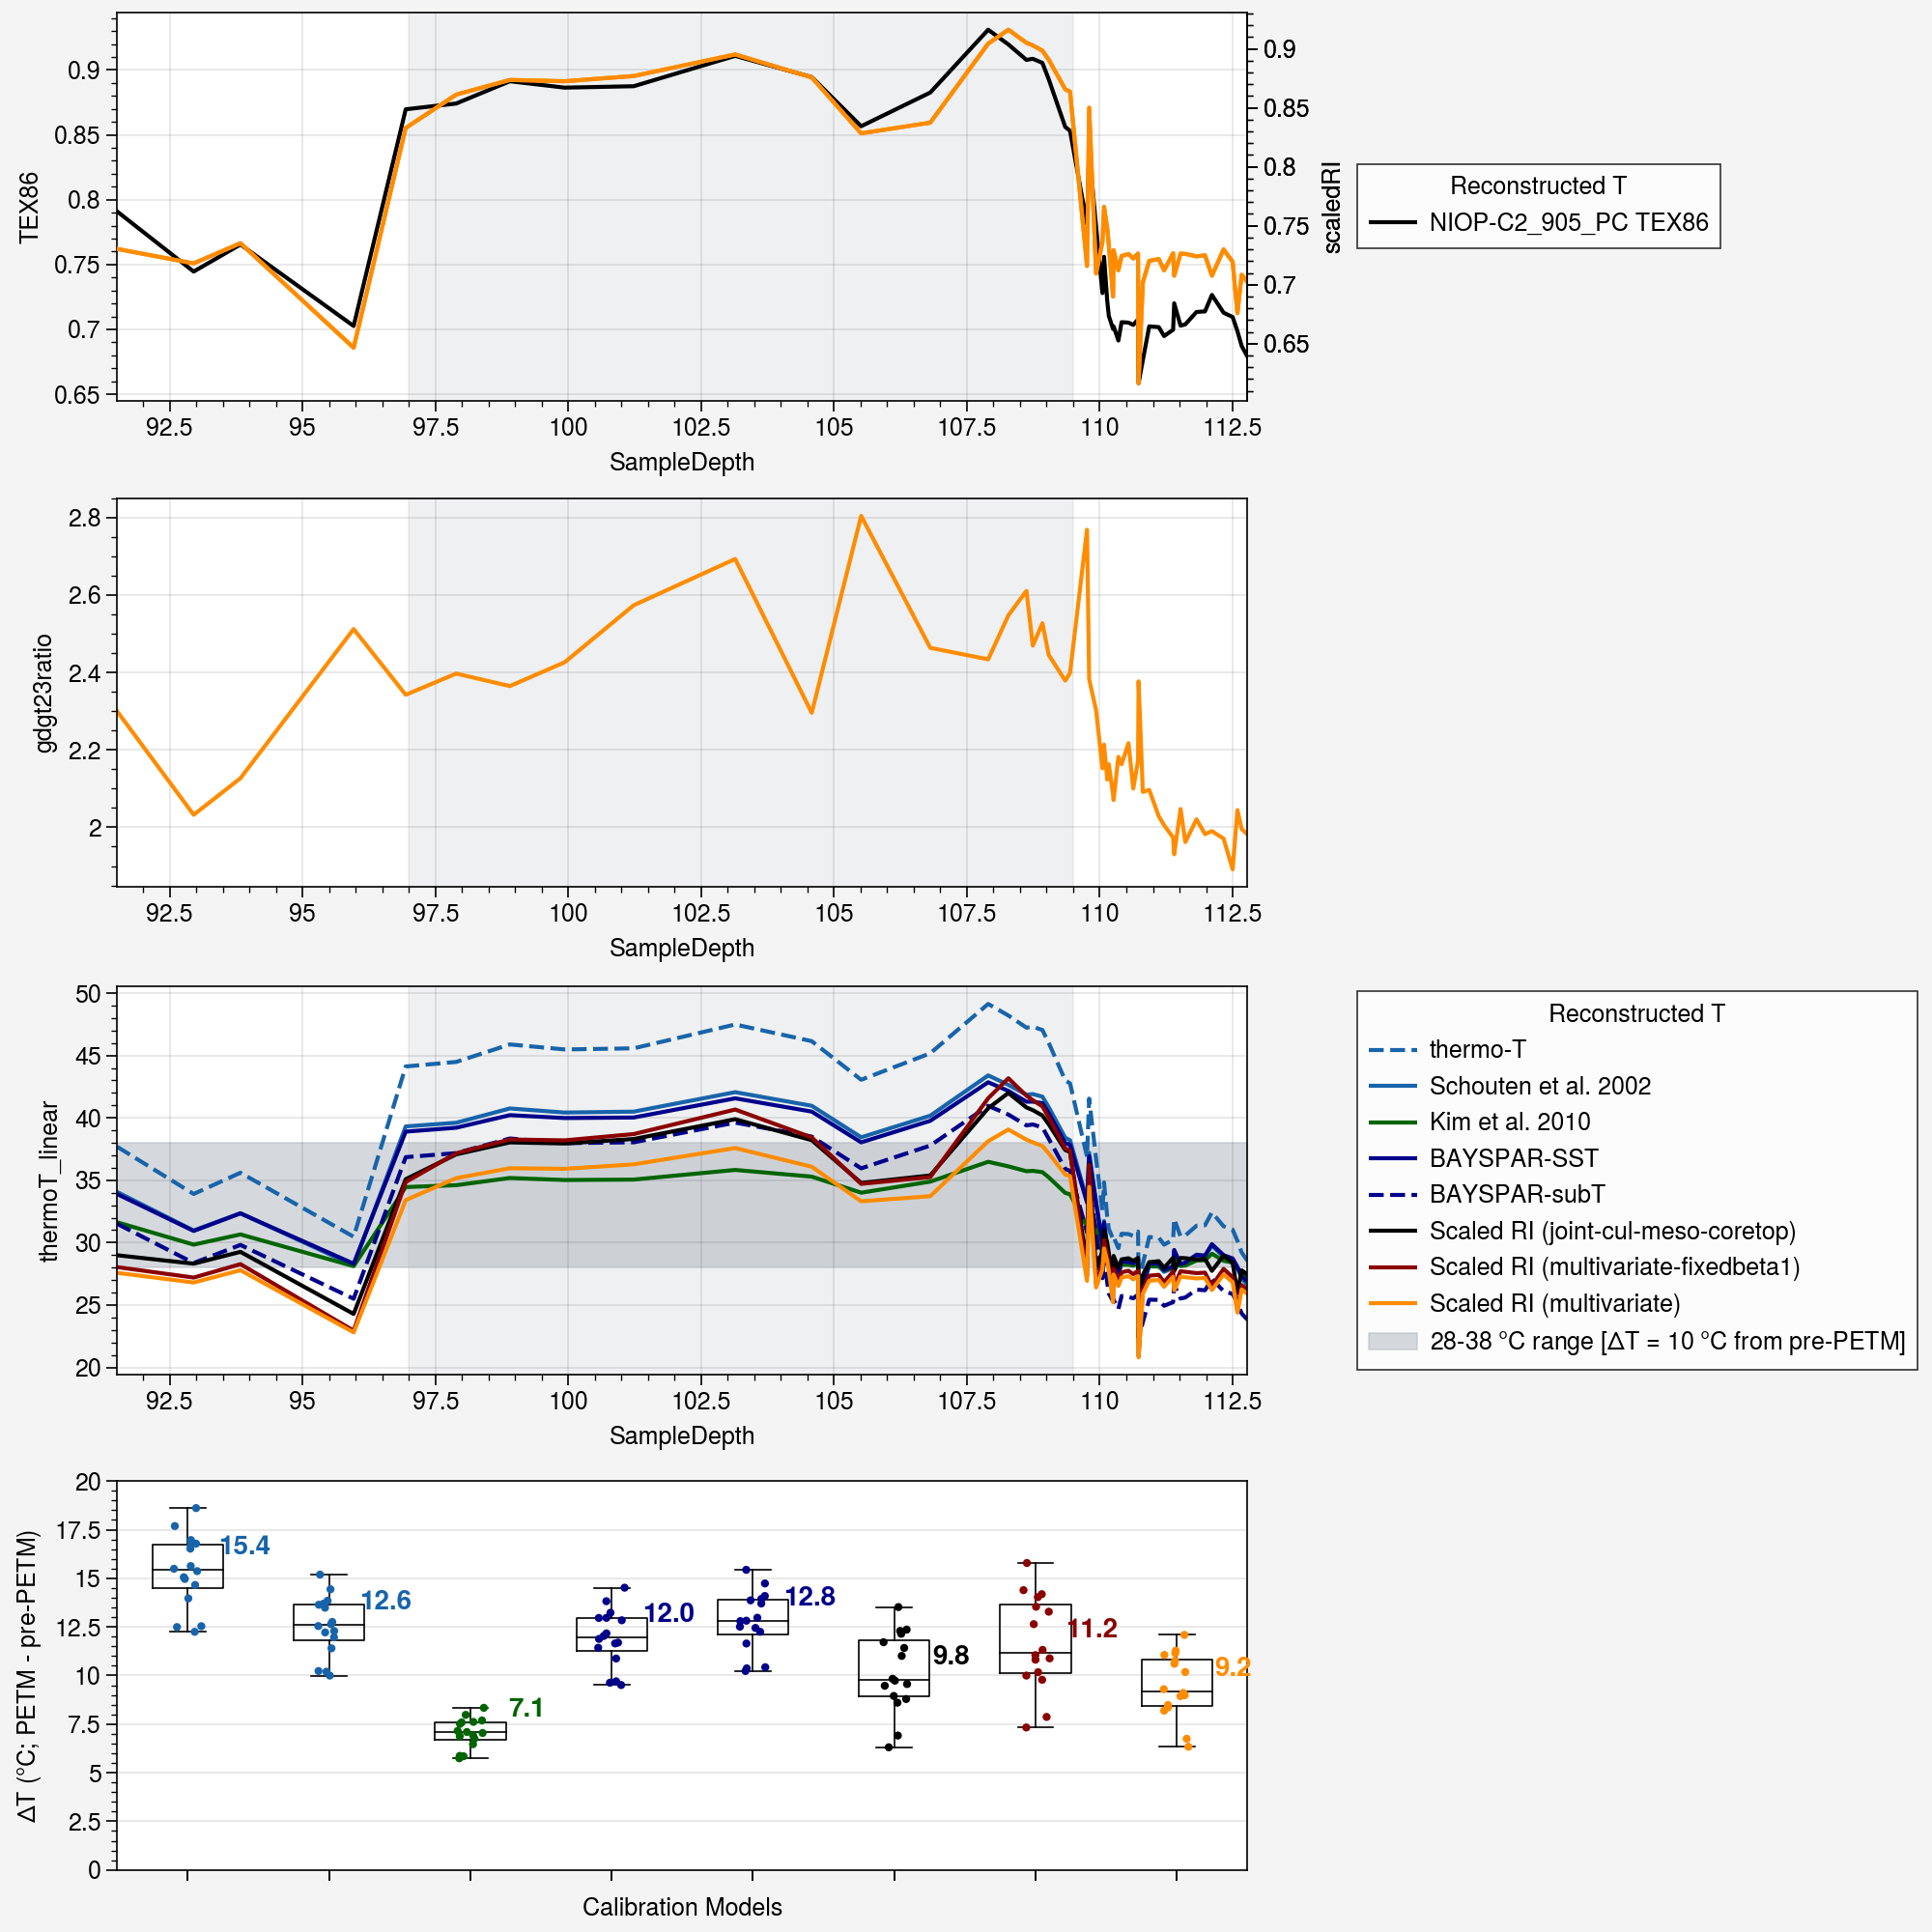

In [57]:
fig, axs = plot.subplots(figsize=(10, 10), nrows=4, share=False)

### plot paleo TEX86

ax = axs[0]
ax.plot(
    paleo_tex_df['SampleDepth'], 
    paleo_tex_df['TEX86'], 
    color='k', 
    label='NIOP-C2_905_PC TEX86'
)

ax2 = ax.twinx()
ax2.plot(
    paleo_tex_df['SampleDepth'], 
    paleo_tex_df['scaledRI'], 
    color='darkorange', 
    label='Scaled RI'
)
h, l = ax.get_legend_handles_labels()
ax.legend(
    h, l, 
    loc='r', 
    fontsize=12, 
    title='Reconstructed T',
    ncol=1
)
######################3
ax = axs[1]

ax.plot(
    paleo_tex_df['SampleDepth'], 
    paleo_tex_df['gdgt23ratio'], 
    color='darkorange', 
    label='Scaled RI'
)

### plot reconstructed SST from TEX86
ax = axs[2]
ax.plot(
    paleo_tex_df['SampleDepth'], 
    paleo_tex_df['thermoT_linear'], 
    color='blue9',
    ls='--', 
    label='thermo-T'
)

ax.plot(
    paleo_tex_df['SampleDepth'], 
    paleo_tex_df['SST_Schouten02'], 
    color='blue9', 
    label='Schouten et al. 2002'
)

ax.plot(
    paleo_tex_df['SampleDepth'], 
    paleo_tex_df['SST_Kim10'], 
    color='darkgreen', 
    label='Kim et al. 2010'
)

ax.plot(
    paleo_tex_df['SampleDepth'],
    paleo_tex_df['SST_bsr'],
    color='darkblue',
    label='BAYSPAR-SST'
)

ax.plot(
    paleo_tex_df['SampleDepth'],
    paleo_tex_df['subT_bsr'],
    color='darkblue',
    ls='--',
    label='BAYSPAR-subT'
)

ax.plot(
    paleo_tex_df['SampleDepth'], 
    paleo_tex_df['SST_scaledRI_joint-cul-meso-coretop'], 
    color='k', 
    label='Scaled RI (joint-cul-meso-coretop)'
)

ax.plot(
    paleo_tex_df['SampleDepth'], 
    paleo_tex_df['SST_scaledRI_joint-cul-meso-coretop-multivariate-fixedbeta1'], 
    color='darkred', 
    label='Scaled RI (multivariate-fixedbeta1)'
)

ax.plot(
    paleo_tex_df['SampleDepth'], 
    paleo_tex_df['SST_scaledRI_joint-cul-meso-coretop-multivariate'], 
    color='darkorange', 
    label='Scaled RI (multivariate)'
)

### plot fill between y from 28-33 degC
ax.fill_between(
    paleo_tex_df['SampleDepth'], 
    28, 38, 
    color='gray5', 
    alpha=0.5, 
    label='28-38 $\degree$C range [$\Delta$T = 10 $\degree$C from pre-PETM]'
)

h, l = ax.get_legend_handles_labels()
ax.legend(
    h, l, 
    loc='r', 
    fontsize=12, 
    title='Reconstructed T',
    ncol=1
)

#### calculate Diff T (mean of SampleDepth > 110m - individual SST)
features = ['thermoT_linear', 'SST_Schouten02', 'SST_Kim10', 'SST_bsr',
            'subT_bsr', 'SST_scaledRI_joint-cul-meso-coretop',
            'SST_scaledRI_joint-cul-meso-coretop-multivariate-fixedbeta1',
            'SST_scaledRI_joint-cul-meso-coretop-multivariate']
colors = ['blue9', 'blue9', 'darkgreen', 'darkblue', 'darkblue', 'k', 'darkred', 'darkorange']
diff_T = {}
for feature in features:
    diff_T[feature] = abs(paleo_tex_df.loc[paleo_tex_df['SampleDepth'] > 110.5, feature].median() - \
                      paleo_tex_df[feature])
diff_T_df = pd.DataFrame(diff_T)
diff_T_df['SampleDepth'] = paleo_tex_df['SampleDepth']

ax = axs[3]

ax.boxplot(
    diff_T_df[diff_T_df['SampleDepth'].between(97,109.5)].iloc[:,:-1],
)

### annotate median values
for i, feature in enumerate(features):
    median_value = diff_T_df[diff_T_df['SampleDepth'].between(97,109.5)][feature].iloc[:].median()
    max_value = diff_T_df[diff_T_df['SampleDepth'].between(97,109.5)][feature].iloc[:].max()
    ax.annotate(
        f'{median_value:.1f}',
        xy=(i, median_value),
        xytext=(i+0.4, median_value+0.5),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color=colors[i]
    )

sns.stripplot(
    data=diff_T_df[diff_T_df['SampleDepth'].between(97,109.5)].iloc[:,:-1],
    ax=ax,
    palette=colors,
    jitter=True,
    size=3,
)

### shaded area for sample depth between 97 and 110
axs[:-1].axvspan(
    97, 109.5, 
    color='gray5', 
    alpha=0.2, 
    label='Sample depth 97-110m'
)


ax.format(
    xlabel='Calibration Models',
    xticklabels=[],
    xlim=(0-0.5, len(features) - 0.5),
    ylabel='$\Delta$T ($\degree$C; PETM - pre-PETM)',
    ylim=(0, 20),
)

In [60]:
### set theme as seaborn
import plotly.io as pio
pio.templates.default = "seaborn"
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# assume paleo_tex_df and diff_T_df are already defined

# define the calibration models & colors for the boxplot panel
features = [
    'thermoT_linear', 'SST_Schouten02', 'SST_Kim10', 'SST_bsr',
    'subT_bsr', 'SST_scaledRI_joint-cul-meso-coretop',
    'SST_scaledRI_joint-cul-meso-coretop-multivariate-fixedbeta1',
    'SST_scaledRI_joint-cul-meso-coretop-multivariate'
]
box_colors = [
    'blue', 'blue', 'darkgreen', 'darkblue',
    'darkblue', 'black', 'darkred', 'darkorange'
]

fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=False,
    row_heights=[0.2, 0.15, 0.35, 0.30],
    vertical_spacing=0.05,
    specs=[
        [{"secondary_y": True}],
        [{}],
        [{}],
        [{}],
    ]
)

# ── Panel 1: TEX86 vs. scaledRI ───────────────────────────────────────────────
fig.add_trace(
    go.Scatter(
        x=paleo_tex_df['SampleDepth'],
        y=paleo_tex_df['TEX86'],
        name='TEX<sub>86</sub>',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='black')
    ),
    row=1, col=1, secondary_y=False
)
fig.add_trace(
    go.Scatter(
        x=paleo_tex_df['SampleDepth'],
        y=paleo_tex_df['scaledRI'],
        name='Scaled RI',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='darkorange')
    ),
    row=1, col=1, secondary_y=True
)
fig.update_yaxes(title_text="TEX<sub>86</sub>", row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="scaledRI", row=1, col=1, secondary_y=True)

### set primary and secondary y-axis ranges to be the same
fig.update_yaxes(
    range=[0.6, 0.95],
    row=1, col=1, secondary_y=False
)
fig.update_yaxes(
    range=[0.6, 0.95],
    row=1, col=1, secondary_y=True
)

# shade SampleDepth 97-109.5 in panels 1–3
fig.add_vrect(
    x0=97, x1=109.5,
    fillcolor="lightgray", opacity=0.2,
    layer="below",
    row="all", col=1
)

# ── Panel 2: gdgt23ratio ─────────────────────────────────────────────────────
fig.add_trace(
    go.Scatter(
        x=paleo_tex_df['SampleDepth'],
        y=paleo_tex_df['gdgt23ratio'],
        name='GDGT-2/GDGT-3',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='darkorange')
    ),
    row=2, col=1
)
fig.update_yaxes(title_text="GDGT-2/GDGT-3", row=2, col=1)

# ── Panel 3: all the SST reconstructions + 28–38°C band ────────────────────
sst_traces = [
    ("thermo-T",          paleo_tex_df['thermoT_linear'],                    dict(dash='dash', color='blue')),
    ("Schouten et al. 2002", paleo_tex_df['SST_Schouten02'],                  dict(color='blue')),
    ("Kim et al. 2010",     paleo_tex_df['SST_Kim10'],                       dict(color='darkgreen')),
    ("BAYSPAR-SST",         paleo_tex_df['SST_bsr'],                         dict(color='darkblue')),
    ("BAYSPAR-subT",        paleo_tex_df['subT_bsr'],                        dict(dash='dash', color='darkblue')),
    ("Scaled RI (cul-meso-coretop)", paleo_tex_df['SST_scaledRI_joint-cul-meso-coretop'], dict(color='black')),
    ("Scaled RI (multivar-fixedβ1)", paleo_tex_df['SST_scaledRI_joint-cul-meso-coretop-multivariate-fixedbeta1'], dict(color='darkred')),
    ("Scaled RI (multivar-freeβ1)",paleo_tex_df['SST_scaledRI_joint-cul-meso-coretop-multivariate'],   dict(color='darkorange')),
]
for name, y, style in sst_traces:
    fig.add_trace(
        go.Scatter(
            x=paleo_tex_df['SampleDepth'],
            y=y,
            name=name,
            legendgroup='Reconstructed T',
            legendgrouptitle_text='Reconstructed T',
            line=style
        ),
        row=3, col=1
    )

# fill the 28–38°C band
fig.add_shape(
    type="rect",
    x0=paleo_tex_df['SampleDepth'].min(),
    x1=paleo_tex_df['SampleDepth'].max(),
    y0=28, y1=38,
    fillcolor="gray",
    opacity=0.5,
    layer="below",
    row=3, col=1
)

## fill between 97 and 109.5 m depth
fig.add_vrect(
    x0=97, x1=109.5,
    fillcolor="gray", opacity=0.5,
    layer="below",
    row=3, col=1
)

fig.update_yaxes(title_text="Temperature (°C)", row=3, col=1)

# ── Panel 4: Box + jitter for ΔT ──────────────────────────────────────────────
#### calculate Diff T (mean of SampleDepth > 110m - individual SST)
features = ['thermoT_linear', 'SST_Schouten02', 'SST_Kim10', 'SST_bsr',
            'subT_bsr', 'SST_scaledRI_joint-cul-meso-coretop',
            'SST_scaledRI_joint-cul-meso-coretop-multivariate-fixedbeta1',
            'SST_scaledRI_joint-cul-meso-coretop-multivariate']
colors = ['blue9', 'blue9', 'darkgreen', 'darkblue', 'darkblue', 'k', 'darkred', 'darkorange']
diff_T = {}
for feature in features:
    diff_T[feature] = abs(paleo_tex_df.loc[paleo_tex_df['SampleDepth'] > 110.5, feature].median() - \
                      paleo_tex_df[feature])
diff_T_df = pd.DataFrame(diff_T)
diff_T_df['SampleDepth'] = paleo_tex_df['SampleDepth']
subset = diff_T_df[diff_T_df['SampleDepth'].between(97, 109.5)]
for feat, col in zip(features, box_colors):
    fig.add_trace(
        go.Box(
            y=subset[feat],
            name=feat,
            boxpoints='all',      # show all points
            jitter=0.3,           # spread them out
            pointpos=0,            # centered on category
            legendgroup='ΔT (°C; PETM – pre-PETM)',
            legendgrouptitle_text='ΔT (°C; PETM – pre-PETM)',
            showlegend=True,
            marker_color=col,
        ),
        row=4, col=1
    )
    # add median annotation
    med = subset[feat].median()
    max = subset[feat].max()
    fig.add_annotation(
        x=feat, y=max + 0.5,  # position above the max value
        text=f"{med:.1f}",
        showarrow=False,
        font=dict(color=col, size=12, family="Arial"),
        row=4, col=1
    )

### remove x-axis tick labels for the boxplot panel
fig.update_xaxes(
    title_text="Calibration Models",
    tickvals=list(range(len(features))),
    ticktext=[''] * len(features),  # empty labels
    row=4, col=1
)

fig.update_yaxes(title_text="ΔT (°C; PETM – pre-PETM)", row=4, col=1)
fig.update_layout(
    height=1000,
    width=1000,
    template='seaborn',
    font=dict(family="TeX Gyre Heros", size=14, color="black"),
    # margin=dict(l=20, r=20, t=20, b=20), 
    legend=dict(
        xref='container',  # position relative to the container
        yref='container',
        orientation="v",      # horizontal legend
        x=0.5,                # center it horizontally
        xanchor="left",  # anchor to the left side
        y=0.5,               # push it below the plot (tweak as needed)
        yanchor="middle",
        tracegroupgap=10,        # space between different legendgroups
        groupclick='toggleitem',  # click either entry to hide/show the whole group "togglegroup"
    ),
    title_text="Wilson Lake PETM showcase"
)

fig.show()

### save the figure as an HTML file
fig.write_html(
    os.path.join(local_github_path, 'html_figures', 'WilsonLakePETM_showcase.html'),
    include_plotlyjs="cdn",   # pull Plotly.js from the CDN
    full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
)

In [31]:
from joblib import Parallel, delayed

In [32]:


paleo_tex_df2 = PhanTEX_df[PhanTEX_df['SiteName']=='MD98-2152'].reset_index(drop=True)
paleo_tex_df2
paleo_tex_df2['thermoT_linear'] = (paleo_tex_df2['TEX86'] - intercept)/slope
paleo_tex_df2['SST_Schouten02'] = predictSSTfromTEX(paleo_tex_df2['TEX86'],method_name='schouten2002')
paleo_tex_df2['SST_Kim10'] = predictSSTfromTEX(paleo_tex_df2['TEX86'],method_name='kim2010_tex86H')

search_tolerance = np.std(paleo_tex_df2['TEX86'], ddof=1) * 2
paleo_tex_df2['SST_bsr'] = bsr.predict_seatemp_analog(paleo_tex_df2['TEX86'],
                                                     prior_mean=30, prior_std=20,
                                                     temptype='sst',search_tol=search_tolerance,
                                                     nens=100).percentile(50)
paleo_tex_df2['subT_bsr'] = bsr.predict_seatemp_analog(paleo_tex_df2['TEX86'],
                                                     prior_mean=30, prior_std=20,
                                                     temptype='subt',search_tol=search_tolerance,
                                                     nens=100).percentile(50)

### predict SST from scaledRI
predT_ensemble = temperature_ensemble_from_scaledRI(
    paleo_tex_df2['scaledRI'].values,
    joint_cul_meso_coretop_post_ds,
    model_name='logistic_fixed_upper'
)

paleo_tex_df2['SST_scaledRI_joint-cul-meso-coretop'] = np.percentile(predT_ensemble, 50, axis=1)

predT_ensemble_fixedbeta1 = temperature_ensemble_from_scaledRI_gdgt23ratio(
    paleo_tex_df2['scaledRI'].values,
    paleo_tex_df2['gdgt23ratio'].values,
    joint_cul_meso_coretop_multivariate_fixedbeta1_post_ds,
    model_name='logistic_fixed_upper_multivariate_fixedbeta1'
)

paleo_tex_df2['SST_scaledRI_joint-cul-meso-coretop-multivariate-fixedbeta1'] = np.percentile(predT_ensemble_fixedbeta1, 50, axis=1)

predT_ensemble_multivariate = temperature_ensemble_from_scaledRI_gdgt23ratio(
    paleo_tex_df2['scaledRI'].values,
    paleo_tex_df2['gdgt23ratio'].values,
    joint_cul_meso_coretop_multivariate_post_ds,
    model_name='logistic_fixed_upper_multivariate'
)
paleo_tex_df2['SST_scaledRI_joint-cul-meso-coretop-multivariate'] = np.percentile(predT_ensemble_multivariate, 50, axis=1)

100%|██████████| 27/27 [04:16<00:00,  9.51s/it]


In [33]:
paleo_uk_df = PhanSST_df[PhanSST_df['ProxyType']=='uk'].reset_index(drop=True)
paleo_uk_df = paleo_uk_df[paleo_uk_df['SiteName']=='MD98-2152'].reset_index(drop=True)
paleo_uk_df = paleo_uk_df.rename(columns={'ProxyValue':'UK37'})
predSST_bsl = bsl.predict_sst(
    paleo_uk_df['UK37'], 
    prior_std=5
)

paleo_uk_df['SST_bsl'] = predSST_bsl.percentile(50)

100%|██████████| 500/500 [00:36<00:00, 13.62it/s]


In [54]:
### set theme as seaborn
import plotly.io as pio
pio.templates.default = "seaborn"
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# assume plot_data and diff_T_df are already defined

plot_data = paleo_tex_df2[paleo_tex_df2['TEX86']>0.5][
    paleo_tex_df2['gdgt23ratio']<10
].reset_index(drop=True)

# define the calibration models & colors for the boxplot panel
features = [
    'thermoT_linear', 'SST_Schouten02', 'SST_Kim10', 'SST_bsr',
    'subT_bsr', 'SST_scaledRI_joint-cul-meso-coretop',
    'SST_scaledRI_joint-cul-meso-coretop-multivariate-fixedbeta1',
    'SST_scaledRI_joint-cul-meso-coretop-multivariate'
]
box_colors = [
    'blue', 'blue', 'darkgreen', 'darkblue',
    'darkblue', 'black', 'darkred', 'darkorange'
]

fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=False,
    row_heights=[0.2, 0.15, 0.35, 0.30],
    vertical_spacing=0.05,
    specs=[
        [{"secondary_y": True}],
        [{}],
        [{}],
        [{}],
    ]
)

# ── Panel 1: TEX86 vs. scaledRI ───────────────────────────────────────────────
fig.add_trace(
    go.Scatter(
        x=plot_data['Age'],
        y=plot_data['TEX86'],
        name='TEX<sub>86</sub>',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='black')
    ),
    row=1, col=1, secondary_y=False
)
fig.add_trace(
    go.Scatter(
        x=plot_data['Age'],
        y=plot_data['scaledRI'],
        name='Scaled RI',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='darkorange')
    ),
    row=1, col=1, secondary_y=True
)
fig.update_yaxes(title_text="TEX<sub>86</sub>", row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="scaledRI", row=1, col=1, secondary_y=True)

### set primary and secondary y-axis ranges to be the same
fig.update_yaxes(
    range=[0.5, 0.8],
    row=1, col=1, secondary_y=False,
)
fig.update_yaxes(
    range=[0.5, 0.8],
    row=1, col=1, secondary_y=True
)


# ── Panel 2: gdgt23ratio ─────────────────────────────────────────────────────
fig.add_trace(
    go.Scatter(
        x=plot_data['Age'],
        y=plot_data['gdgt23ratio'],
        name='GDGT-2/GDGT-3',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='darkorange')
    ),
    row=2, col=1
)

fig.update_yaxes(title_text="GDGT-2/GDGT-3", row=2, col=1)

# ── Panel 3: all the SST reconstructions + 28–38°C band ────────────────────
sst_traces = [
    ("U<sup>K'</sup><sub>37</sub> BAYSPLINE-SST", paleo_uk_df['SST_bsl'], dict(color='purple')),
    ("thermo-T",          plot_data['thermoT_linear'],                    dict(dash='dash', color='blue')),
    ("Schouten et al. 2002", plot_data['SST_Schouten02'],                  dict(color='blue')),
    ("Kim et al. 2010",     plot_data['SST_Kim10'],                       dict(color='darkgreen')),
    ("BAYSPAR-SST",         plot_data['SST_bsr'],                         dict(color='darkblue')),
    ("BAYSPAR-subT",        plot_data['subT_bsr'],                        dict(dash='dash', color='darkblue')),
    ("Scaled RI (cul-meso-coretop)", plot_data['SST_scaledRI_joint-cul-meso-coretop'], dict(color='black')),
    ("Scaled RI (multivar-fixedβ1)", plot_data['SST_scaledRI_joint-cul-meso-coretop-multivariate-fixedbeta1'], dict(color='darkred')),
    ("Scaled RI (multivar-freeβ1)",plot_data['SST_scaledRI_joint-cul-meso-coretop-multivariate'],   dict(color='darkorange')),
]
for name, y, style in sst_traces:
    if name == 'UK37':
        fig.add_trace(
            go.Scatter(
                x=paleo_uk_df['Age'],
                y=y,
                name=name,
                legendgroup='Reconstructed T',
                legendgrouptitle_text='Reconstructed T',
                line=style,
                mode='markers+lines'
            ),
            row=3, col=1
        )
    else:
        fig.add_trace(
            go.Scatter(
                x=plot_data['Age'],
                y=y,
                name=name,
                legendgroup='Reconstructed T',
                legendgrouptitle_text='Reconstructed T',
                line=style
            ),
            row=3, col=1
        )



fig.update_yaxes(title_text="Temperature (°C)", row=3, col=1)

# ── Panel 4: Box + jitter for ΔT ──────────────────────────────────────────────
### calculate Diff T (mean of glacial (TEX86 < 0.61) - mean of interglacial (TEX86 > 0.67))
features = ['thermoT_linear', 'SST_Schouten02', 'SST_Kim10', 'SST_bsr',
            'subT_bsr', 'SST_scaledRI_joint-cul-meso-coretop',
            'SST_scaledRI_joint-cul-meso-coretop-multivariate-fixedbeta1',
            'SST_scaledRI_joint-cul-meso-coretop-multivariate']
diff_T = {}
diff_T['SST_bsl'] = abs(
    paleo_uk_df.loc[paleo_uk_df['UK37'] < 0.88, 'SST_bsl'].mean() -
    paleo_uk_df.loc[paleo_uk_df['UK37'] > 0.965, 'SST_bsl'])
for feature in features:
    diff_T[feature] = abs(
        plot_data.loc[plot_data['TEX86'] < 0.58, feature].mean() - 
        plot_data.loc[plot_data['TEX86'] > 0.65, feature]
    )
diff_T_df = pd.DataFrame(diff_T)
diff_T_df['Age'] = plot_data['Age']
diff_T_df['TEX86'] = plot_data['TEX86']
subset = diff_T_df[diff_T_df['TEX86'] > 0.64]
box_colors = [
    'purple','blue', 'blue', 'darkgreen', 'darkblue',
    'darkblue', 'black', 'darkred', 'darkorange'
]
features2 = ['SST_bsl','thermoT_linear', 'SST_Schouten02', 'SST_Kim10', 'SST_bsr',
            'subT_bsr', 'SST_scaledRI_joint-cul-meso-coretop',
            'SST_scaledRI_joint-cul-meso-coretop-multivariate-fixedbeta1',
            'SST_scaledRI_joint-cul-meso-coretop-multivariate']
for feat, col in zip(features2, box_colors):
    fig.add_trace(
        go.Box(
            y=subset[feat],
            name=feat,
            boxpoints='all',      # show all points
            jitter=0.3,           # spread them out
            pointpos=0,            # centered on category
            legendgroup='ΔT (°C; interglacial - glacial)',
            legendgrouptitle_text='ΔT (°C; interglacial - glacial)',
            showlegend=True,
            marker_color=col,
        ),
        row=4, col=1
    )
    # add median annotation
    med = subset[feat].median()
    max = subset[feat].max()
    fig.add_annotation(
        x=feat, y=max + 0.5,  # position above the max value
        text=f"{med:.1f}",
        showarrow=False,
        font=dict(color=col, size=12, family="Arial"),
        row=4, col=1
    )

fig.update_yaxes(
    title_text="ΔT (°C; interglacial - glacial)",
    row=4, col=1,
    range=[0, 15]
)


### remove x-axis tick labels for the boxplot panel
fig.update_xaxes(
    title_text="Calibration Models",
    tickvals=list(range(len(features))),
    ticktext=[''] * len(features),  # empty labels
    row=4, col=1
)

# fig.update_yaxes(title_text="ΔT (°C; PETM – pre-PETM)", row=4, col=1)

fig.update_layout(
    height=1000,
    width=1000,
    template='seaborn',
    font=dict(family="TeX Gyre Heros", size=14, color="black"),
    # margin=dict(l=20, r=20, t=20, b=20), 
    legend=dict(
        xref='container',  # position relative to the container
        yref='container',
        orientation="v",      # horizontal legend
        x=0.6,                # center it horizontally
        xanchor="left",  # anchor to the left side
        y=0.5,               # push it below the plot (tweak as needed)
        yanchor="middle",
        tracegroupgap=10,        # space between different legendgroups
        groupclick='toggleitem',  # click either entry to hide/show the whole group "togglegroup"
    ),
    title_text="MD98-2152 G-IG showcase"
)

fig.show()

### save the figure as an HTML file
fig.write_html(
    os.path.join(local_github_path, 'html_figures', 'MD98-2152_G-IG_showcase.html'),
    include_plotlyjs="cdn",   # pull Plotly.js from the CDN
    full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
)